Function for Loading the Dataset

In [1]:
def load_mnist_data(path):
    with open(path, 'rb') as f:
        data = f.read()
        
    magic_number = int.from_bytes(data[0:4], 'big')
    count_images = int.from_bytes(data[4:8], 'big')
    rows = int.from_bytes(data[8:12], 'big')
    cols = int.from_bytes(data[12:16], 'big')
    
    if magic_number != 2051:
        raise ValueError("Invalid file. Expected number is 2051")
    
    images = []
    offset = 16
    size = rows * cols
    
    for _ in range(count_images):
        image = data[offset:offset + size]
        # normalize the pixel values between 0 and 1 for better execution
        image = [pixel / 255.0 for pixel in image]
        images.append(image)
        offset += size
        
    return images, rows, cols

def load_mnist_labels(path):
    with open(path, 'rb') as f:
        data = f.read()
        
    magic_number = int.from_bytes(data[0:4], 'big')
    count_labels = int.from_bytes(data[4:8], 'big')
    
    if magic_number != 2049:
        raise ValueError("Invalid file. Expected number is 2049")
    
    labels = list(data[8:8 + count_labels])
    return labels

In [2]:
data_dir = "data"

try:
    open(data_dir + "/train-images.idx3-ubyte", "rb").close()
except FileNotFoundError:
    data_dir = "../../data"

train_images, rows, cols = load_mnist_data(data_dir + "/train-images.idx3-ubyte")
train_labels = load_mnist_labels(data_dir + "/train-labels.idx1-ubyte")

test_images, _, _ = load_mnist_data(data_dir + "/t10k-images.idx3-ubyte")
test_labels = load_mnist_labels(data_dir + "/t10k-labels.idx1-ubyte")

print("Training images:", len(train_images))
print("Training labels:", len(train_labels))
print("Test images:", len(test_images))
print("Test labels:", len(test_labels))
print("Image size:", rows, "x", cols)
print("First label:", train_labels[0])

Training images: 60000
Training labels: 60000
Test images: 10000
Test labels: 10000
Image size: 28 x 28
First label: 5


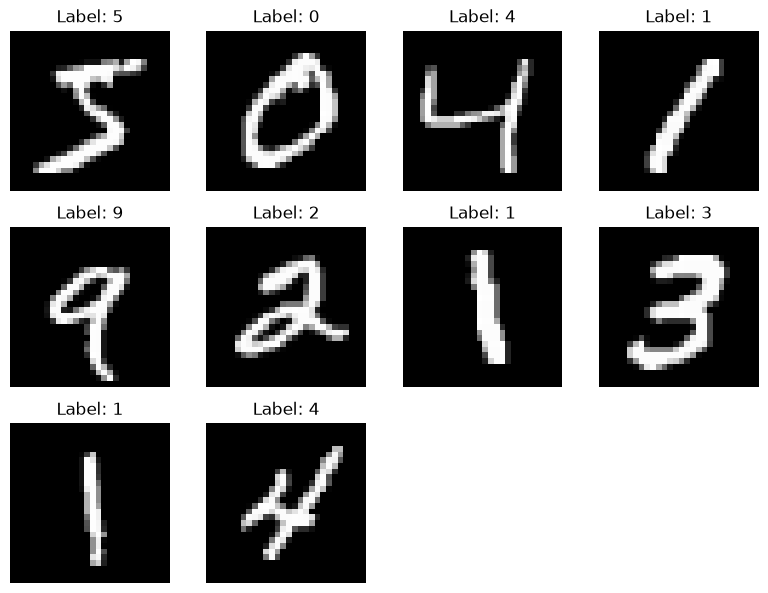

In [3]:
import matplotlib.pyplot as plt

def show_images(images, labels, rows=28, cols = 28, count=10):
    plt.figure(figsize=(8,8))
    
    for i in range(count):
        image_2D = [
            images[i][r * cols:(r+1) * cols]
            for r in range(rows)
        ]
        
        plt.subplot(4,4, i + 1)
        plt.imshow(image_2D, cmap='gray')
        plt.title(f"Label: {labels[i]}")
        plt.axis("off")
        
    plt.tight_layout()
    plt.show()
    
show_images(train_images, train_labels, rows=28, cols=28, count=10)

In [4]:
def reshape_images(image, rows = 28, cols = 28):
    return [
        image[i * cols:(i + 1) * cols]
        for i in range(rows)
    ]

In [5]:
train_images = [reshape_images(image, rows, cols) for image in train_images]
test_images = [reshape_images(image, rows, cols) for image in test_images]

In [12]:
print("number of training images:", len(train_images))
print("rows in first image:", len(train_images[0]))
print("cols in first image:", len(train_images[0][0]))
print("first pixel value:", train_images[0][0][0])

number of training images: 60000
rows in first image: 28
cols in first image: 28
first pixel value: 0.0


In [15]:
train_images_cnn = [
    [image] for image in train_images
]

test_images_cnn = [
    [image] for image in test_images
]



In [20]:
print(len(train_images_cnn[0]))
print(len(train_images_cnn[0][0]))
print(len(train_images_cnn[0][0][0]))

1
28
28


In [22]:
import random
import math

def init_filters(num_filters, channels, kernel_size):
    scale = math.sqrt(2 / (channels * kernel_size * kernel_size))
    
    filters = []
    
    for _ in range(num_filters):
        one_filter = []
        
        for _ in range(channels):
            channel_kernel = []
            
            for _ in range(kernel_size):
                row = [
                    random.uniform(-scale, scale)
                    for _ in range(kernel_size)
                ]
                channel_kernel.append(row)
            one_filter.append(channel_kernel)
        filters.append(one_filter)
        
    biases = [0.0 for _ in range(num_filters)]
    
    return filters, biases

In [23]:
filters, biases = init_filters(num_filters = 8, channels = 1, kernel_size = 3)

In [25]:
num_filters = len(filters)
print("Number of filters:", num_filters)
print("Filter shape:", len(filters[0]), "x", len(filters[0][0]), "x", len(filters[0][0][0]))
print("Bias shape:", len(biases))

Number of filters: 8
Filter shape: 1 x 3 x 3
Bias shape: 8
